# Experiment of CLM with or without Refinement Block on New framework MME embeddings **(only Foundation)**

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2

from gbmhackathon.training.predictive import *
from gbmhackathon.models.mme import MultiModalEncoder, ClinicalLinkageModule, concat_modality_embeddings
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction, RankMe, make_patient_map, RegularizationModule
from gbmhackathon.utils.module_functions import instantiate
from gbmhackathon.utils.model_saving import *
from gbmhackathon.training.loops import modality_wise_contrastive_learning, new_predictive_learning, build_run_name
from gbmhackathon.training.cv import *
from gbmhackathon.utils.analysis import *
from gbmhackathon.viz.viz_experiment import *
from gbmhackathon.s3_loader import load_s3

import os, time
from copy import deepcopy
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
# To investigate gradients
from torchviz import make_dot

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam

In [3]:
torch.set_num_threads(32)
torch.get_num_threads()

32

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)

## Dataset preparation

In [5]:
ALL_POSSIBLE_EMBS = ["025-03-22_12-27_phikon_emb_V1.pkl",
                    "2025-03-23_18-32_spatial_emb_V1.pkl",
                    "2025-03-30_14-23_clinical_emb_V1.pkl",
                    "2025-04-05_13-40_wes_emb_V1.pkl",
                    "2025-04-26_16-02_connectivities_spatial_V1.pkl",
                    "2025-05-03_10-15_bulk_emb_V1.pkl",
                    "2025-05-04_02-35_scRNA_emb_V1.pkl",
                    "2025-05-25_14-36_new_clinical_emb_V1.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_mds.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_pca.pkl",
                    "2025-06-01_15-11_bulk_emb_V1_umap.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_mds.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_pca.pkl",
                    "2025-06-01_15-11_embeddings_HnE_OptimusH0_umap.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_mds.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_pca.pkl",
                    "2025-06-01_15-11_scRNA_emb_V1_umap.pkl",
                    "2025-06-01_15-11_wes_emb_V1_mds.pkl",
                    "2025-06-01_15-11_wes_emb_V1_pca.pkl",
                    "2025-06-01_15-11_wes_emb_V1_umap.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_mds.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_pca.pkl",
                    "2025-06-01_18-36_raw_bulk_emb_umap.pkl",
                    "2025-06-01_21-03_raw_spatial_emb_pca.pkl",
                    "2025-06-01_22-10_raw_spatial_emb_umap.pkl",
                    "2025-06-02_21-09_raw_scRNA_emb_pca.pkl",
                    "2025-06-02_22-50_raw_scRNA_emb_umap.pkl",
                    "embeddings_HnE_OptimusH0.pkl"]

### You can choose any embedding from the above

In [6]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-05-25_14-36_new_clinical_emb_V1.pkl", # Needed to retrieve targets, will be removed afterwards
"bulk":"2025-05-03_10-15_bulk_emb_V1.pkl",
"scRNA":"2025-05-04_02-35_scRNA_emb_V1.pkl"
                }
pkl_storage_folder = "embedding_V1"

In [7]:
dataset = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, 
                                    device=device, 
                                    dropout=1.0, 
                                    normalize=True, 
                                    remove_clinical=True)
print(f"Dataset size: {len(dataset)}")
BATCH_SIZE = 742 #582
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_predictive, generator=torch.Generator(device=dataset.device))

cas 2 : device reconnu : cuda 
Using device: cuda
Normalization applied successfully
By keeping 100.00% of dropout augmented samples we went from:
94 dropout samples (45.19% dropout in dataset) -- to --> 94 dropout samples (45.19% dropout in dataset)
Dataset size: 208


### To make a batch of True patient samples only (no dropout)

In [8]:
# Batch of all true samples (no dropout augmented samples)
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient if 'd' not in dataset.ind2patient[idx]]
batch_all = collate_predictive(batch_all)

### Needed to know the size of the inputs (it is used later on to define model configurations)

In [9]:
raw_emb = next(iter(dataloader))[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

clinical torch.Size([208, 20])
wes torch.Size([208, 1790])
bulk torch.Size([208, 60])
scRNA torch.Size([208, 64])


### Patient map is used by the contrastive loss to identify dropout and true samples which are from the same original patient

In [10]:
patient_map = make_patient_map(dataset)

In [11]:
dataset_II = PredictiveLearningDataset(name_emb_dict, pkl_storage_folder, device=device, dropout=0.0, normalize=True)
print(f"Dataset size: {len(dataset_II)}")

cas 2 : device reconnu : cuda 
Using device: cuda
Normalization applied successfully
Dataset size: 114


## Load Trained MME with new framework

In [12]:
model_path = '../saved_models/new_onlyFoundation_mme.ckpt'
cfg_model_path = '../saved_models/cfg_new_onlyFoundation_mme.ckpt'
mme = load_model(MultiModalEncoder, model_path, cfg_model_path, device=dataset_II.device, training=False)

Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found
Using device: cuda
No potential residual connections found

Model succesfully loaded on device cuda. Model currently in inference mode.


In [13]:
# Retrieve the output size of each encoder in the MME
all_encoder_output_sizes = [mme.config[mod_cfg]['net_config']['layers'][-1] for mod_cfg in mme.config.keys() if mme.config[mod_cfg] is not None]
output_size = int(np.sum(all_encoder_output_sizes).item())

### Configuration of the clinical linkage module

In [14]:
dropout = 0.2
layers = [output_size,1024,512,128]
act_fn = [nn.GELU] * (len(layers) - 1) + [None]
norm_fn = nn.BatchNorm1d
reg_head_cfg = {"layers": layers + [1],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}
binary_clf_head_cfg = {"layers": layers + [2],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}
multi_clf_head_cfg = {"layers": layers + [3],
        "dropout": dropout,
        # NO ACTIVATION FOR THE LAST LAYER ! (no need for regression and already in the loss module for classification)
        "act_fn":act_fn,
        "norm_layer":norm_fn,
        "device":device}

In [15]:
os_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
pfs_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": reg_head_cfg}
recurrency_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": binary_clf_head_cfg}
mgmt_head_cfg = {"net_type": "mlp",
            "device": device,
            "net_config": multi_clf_head_cfg}

In [16]:
# ATTENTION !!!! MUST BE THIS EXACT ORDER FOR PREDICTIVE TASKS: 
# ['os_years', 'pfs_years', 'largest_diameter_of_the_primary_tumour_mm_duplicated_0', 'recurrent_sample']
# OR ['os_years', 'pfs_years', 'recurrent_sample', 'mgmt_promoter_methylation'] if using latest targets
predictive_cfg = {"heads_configs":{"os": os_head_cfg,
                  "pfs": pfs_head_cfg,
                  "recurrency":recurrency_head_cfg,
                  "mgmt":mgmt_head_cfg}}

clf_targets = ['recurrency', 'mgmt']
clf_targets_dict = {'recurrency':2, 'mgmt':3}

### Let's try with a refinement block

In [17]:
refinement_cfg = {"emb_size": output_size,
                "cross_modality_heads": 1,
                "cross_mods_fc_size": 128,
                "avail_mods_fc_size": 32,
                "avail_mods_len":len(all_encoder_output_sizes),
                "avail_mods_dense_size": 32,
                "avail_mods_heads": 1,
                "act_fn": nn.GELU,
                "dropout": dropout,
                "device": device}

# Monte Carlo Cross Validation
Instantiation must be done for each fold

In [18]:
n_splits = 30
test_size = 0.8
t_batch = 32 # training batch size
v_batch = 256 # evaluation batch size
random_state = 6262

In [19]:
cv_scores = {task:[] for task in predictive_cfg["heads_configs"].keys()}
t0 = time.time()
for train_loader, val_loader in get_mccv_loaders(dataset_II, 
                                                 collate_predictive,
                                                 n_splits=n_splits, 
                                                 test_size=test_size, 
                                                 train_batch_size=t_batch, 
                                                 val_batch_size=v_batch, 
                                                 device=device, 
                                                 random_state=random_state):
    EPOCHS_II = 150
    base_lr_II = 1e-4
    eta_min_coef = 0.05
    scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
    scheduler_II_cfg = {"T_max":EPOCHS_II,
                        "eta_min":"dynamic"}
    clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)
    # Optimization for Phase II
    optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
    scheduler_II_cfg["optimizer"] = optimizer_II
    if "eta_min" in scheduler_II_cfg.keys():
        if scheduler_II_cfg["eta_min"] == "dynamic":
            scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
    scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

    # Training loop with validation at the end of each epoch on the validation set
    new_predictive_learning(mme, clm, 
                          train_loader,
                          EPOCHS_II, 
                          base_lr_II, 
                          optimizer_II,
                          scheduler_II,
                          clf_targets_dict,
                          v_dataloader=val_loader,
                          reg_loss_fn = nn.MSELoss(),
                          clf_loss_fn = nn.CrossEntropyLoss(),
                          batch_all=batch_all, # No worries, it is used in eval mode under the hood so not seen by model
                          make_gifs=False,
                          )
    # Evaluation metrics are computed on the validation set after training.
    clm.eval()
    all_val_predictions = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    all_val_targets = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    for batch in val_loader:
        patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
        
        contrastive_outputs = mme(X_dict)
        task_outputs, patient_embeddings = clm(contrastive_outputs, avail_mods)
        
        overall_loss = torch.tensor(0, device=device)
        # Regression losses
        for i, key in enumerate(task_outputs.keys()):
            if key not in clf_targets:
                all_val_predictions[key].append(task_outputs[key].squeeze())
                all_val_targets[key].append(batch_targets[:,i])
            
        # Classification losses
        for i, key in enumerate(clf_targets):
            if i == 0:
                start_idx = len(task_outputs.keys()) - len(clf_targets)
            else:
                start_idx = end_idx - 1 # last end_idx
            # clf_targets_dict is a dict that maps each clf target to the number of classes it holds
            end_idx = start_idx + clf_targets_dict[key]
            all_val_predictions[key].append(task_outputs[key])
            all_val_targets[key].append(batch_targets[:,start_idx:end_idx])
            
    for task in all_val_predictions.keys():
        all_task_pred = torch.cat(all_val_predictions[task], dim=0).to(dataset.device)
        all_task_true = torch.cat(all_val_targets[task], dim=0).to(dataset.device)
        if task not in clf_targets:
            score = torch.sqrt(nn.MSELoss()(all_task_pred, all_task_true)).item()
        else:
            score = f1_score(torch.argmax(all_task_true, dim=1).cpu().detach().numpy(), 
                             torch.argmax(all_task_pred, dim=1).cpu().detach().numpy(), 
                             average='weighted', zero_division=0)
        cv_scores[task].append(score)
reg_dict = {key:val for key, val in cv_scores.items() if key in ['os', 'pfs']}
clf_dict = {key:val for key, val in cv_scores.items() if key in clf_targets}
runtime = time.time() - t0

Using device: cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
EPOCH 1 TOTAL TRAINING LOSS: 6.9298
EPOCH 2 TOTAL TRAINING LOSS: 4.381288
EPOCH 3 TOTAL TRAINING LOSS: 4.707437
EPOCH 4 TOTAL TRAINING LOSS: 4.992116
EPOCH 5 TOTAL TRAINING LOSS: 3.750401
EPOCH 6 TOTAL TRAINING LOSS: 4.663594
EPOCH 7 TOTAL TRAINING LOSS: 2.814428
EPOCH 8 TOTAL TRAINING LOSS: 2.471046
EPOCH 9 TOTAL TRAINING LOSS: 2.508537
EPOCH 10 TOTAL TRAINING LOSS: 3.25476
EPOCH 11 TOTAL TRAINING LOSS: 2.758332
EPOCH 12 TOTAL TRAINING LOSS: 3.534839
EPOCH 13 TOTAL TRAINING LOSS: 2.135305
EPOCH 14 TOTAL TRAINING LOSS: 3.425747
EPOCH 15 TOTAL TRAINING LOSS: 2.551808
EPOCH 16 TOTAL TRAINING LOSS: 2.639110
EPOCH 17 TOTAL TRAINING LOSS: 2.159301
EPOCH 18 TOTAL TRAINING LOSS: 2.369948
EPOCH 19 TOTAL TRAINING LOSS: 3.025019
EPOCH 20 TOTAL TRAINING LOSS: 3.146293
EPOCH 21 TOTAL TRAINING LOSS: 3.291833
EPOCH 22 TOTAL TRAINING LO

In [20]:
run_name = build_run_name(
    model=clm,
    epochs=EPOCHS_II,
    base_lr=base_lr_II,
    eta_min_coef=eta_min_coef,
    scheduler_class=scheduler_II_class,
    scheduler_cfg=scheduler_II_cfg,
    contrastive_loss_cfg=None,
    modality_list=list(name_emb_dict.keys())
)

In [21]:
get_cv_results(reg_dict, clf_dict, 'new_onlyFoundation_' + run_name, time=runtime, save=True)

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,new_noFoundation_ClinicalLinkageModule_E150_lr...,30,382.019985,1.08798,1.118536,1.152059,1.046658,1.086701,1.136396,0.529162,0.54672,0.566686,0.419443,0.44775,0.470433,2.205237,0.99447,0.139866,0.182516


## **Results**

In [22]:
evaluations = {}
for task in cv_scores.keys():
    evaluations[task] = np.mean(cv_scores[task])
    print(f"MCCV score on task {task}: {evaluations[task]}")

MCCV score on task os: 1.1185356577237446
MCCV score on task pfs: 1.0867009341716767
MCCV score on task recurrency: 0.5467201770470641
MCCV score on task mgmt: 0.44774988240439567


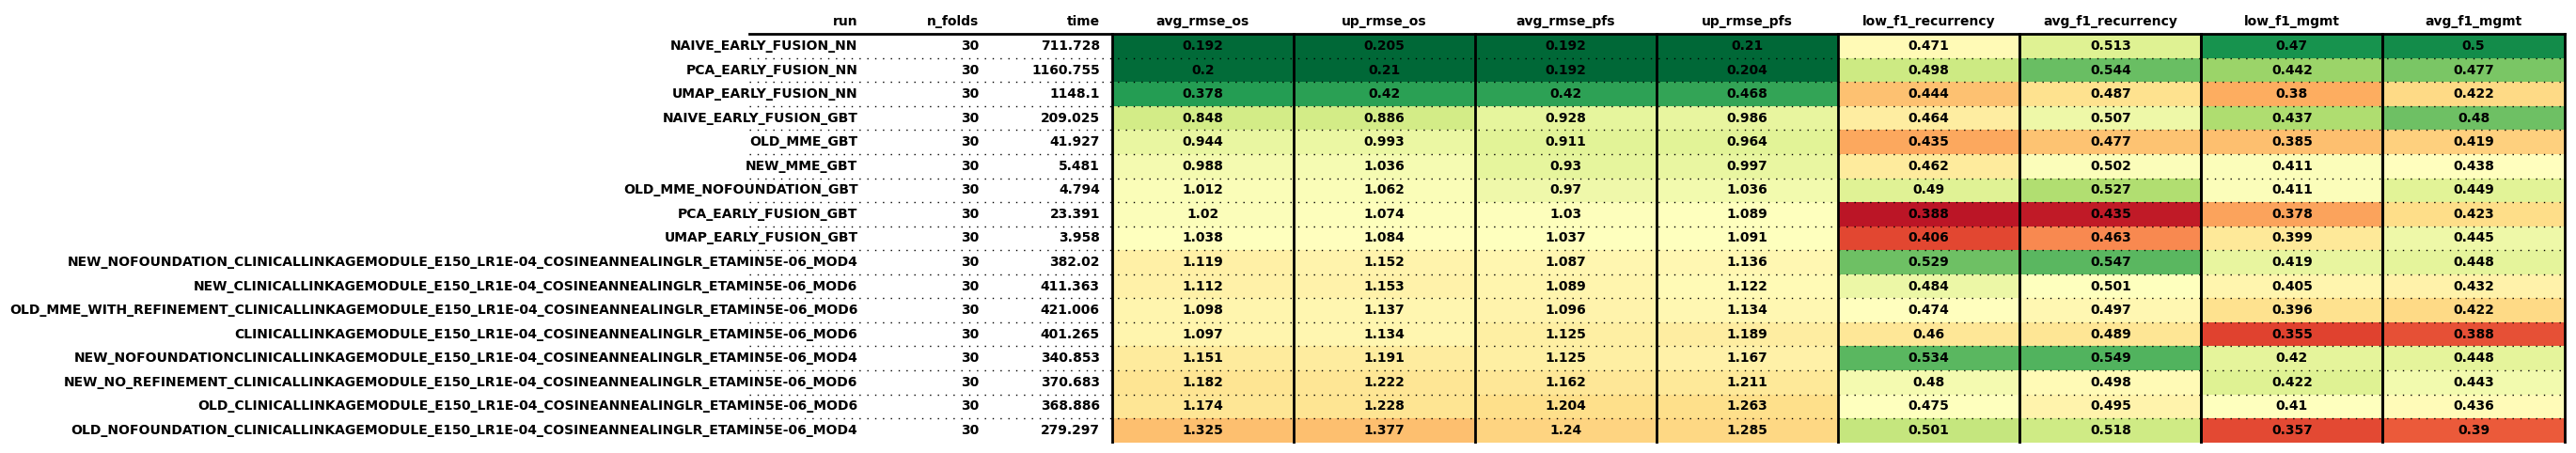

In [23]:
plot_cv_table('../results/cv_results.csv', save=True, out_file="results/cv_results_table.pdf")

## Save ClinicalLinkageModule

In [24]:
save_model(clm, '../saved_models/new_onlyFoundation_clm.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/new_noFoundation_clm.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_noFoundation_clm.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


(PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/new_noFoundation_clm.ckpt'),
 PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_noFoundation_clm.ckpt'))

## Without Refinement

In [25]:
refinement_cfg = None

In [26]:
cv_scores = {task:[] for task in predictive_cfg["heads_configs"].keys()}
t0 = time.time()
for train_loader, val_loader in get_mccv_loaders(dataset_II, 
                                                 collate_predictive,
                                                 n_splits=n_splits, 
                                                 test_size=test_size, 
                                                 train_batch_size=t_batch, 
                                                 val_batch_size=v_batch, 
                                                 device=device, 
                                                 random_state=random_state):
    EPOCHS_II = 150
    base_lr_II = 1e-4
    eta_min_coef = 0.05
    scheduler_II_class = torch.optim.lr_scheduler.CosineAnnealingLR
    scheduler_II_cfg = {"T_max":EPOCHS_II,
                        "eta_min":"dynamic"}
    clm = ClinicalLinkageModule(refinement_cfg=refinement_cfg,
                            predictive_cfg=predictive_cfg)
    # Optimization for Phase II
    optimizer_II = Adam(clm.parameters(), lr=base_lr_II)
    scheduler_II_cfg["optimizer"] = optimizer_II
    if "eta_min" in scheduler_II_cfg.keys():
        if scheduler_II_cfg["eta_min"] == "dynamic":
            scheduler_II_cfg["eta_min"] = eta_min_coef * base_lr_II
    scheduler_II = instantiate(scheduler_II_cfg, scheduler_II_class)

    # Training loop with validation at the end of each epoch on the validation set
    new_predictive_learning(mme, clm, 
                          train_loader,
                          EPOCHS_II, 
                          base_lr_II, 
                          optimizer_II,
                          scheduler_II,
                          clf_targets_dict,
                          v_dataloader=val_loader,
                          reg_loss_fn = nn.MSELoss(),
                          clf_loss_fn = nn.CrossEntropyLoss(),
                          batch_all=batch_all, # No worries, it is used in eval mode under the hood so not seen by model
                          make_gifs=False,
                          )
    # Evaluation metrics are computed on the validation set after training.
    clm.eval()
    all_val_predictions = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    all_val_targets = {task:[] for task in predictive_cfg["heads_configs"].keys()}
    for batch in val_loader:
        patient_ids, modalities, X_dict, avail_mods, batch_targets, targets_names = batch
        
        contrastive_outputs = mme(X_dict)
        task_outputs, patient_embeddings = clm(contrastive_outputs, avail_mods)
        
        overall_loss = torch.tensor(0, device=device)
        # Regression losses
        for i, key in enumerate(task_outputs.keys()):
            if key not in clf_targets:
                all_val_predictions[key].append(task_outputs[key].squeeze())
                all_val_targets[key].append(batch_targets[:,i])
            
        # Classification losses
        for i, key in enumerate(clf_targets):
            if i == 0:
                start_idx = len(task_outputs.keys()) - len(clf_targets)
            else:
                start_idx = end_idx - 1 # last end_idx
            # clf_targets_dict is a dict that maps each clf target to the number of classes it holds
            end_idx = start_idx + clf_targets_dict[key]
            all_val_predictions[key].append(task_outputs[key])
            all_val_targets[key].append(batch_targets[:,start_idx:end_idx])
            
    for task in all_val_predictions.keys():
        all_task_pred = torch.cat(all_val_predictions[task], dim=0).to(dataset.device)
        all_task_true = torch.cat(all_val_targets[task], dim=0).to(dataset.device)
        if task not in clf_targets:
            score = torch.sqrt(nn.MSELoss()(all_task_pred, all_task_true)).item()
        else:
            score = f1_score(torch.argmax(all_task_true, dim=1).cpu().detach().numpy(), 
                             torch.argmax(all_task_pred, dim=1).cpu().detach().numpy(), 
                             average='weighted', zero_division=0)
        cv_scores[task].append(score)
reg_dict = {key:val for key, val in cv_scores.items() if key in ['os', 'pfs']}
clf_dict = {key:val for key, val in cv_scores.items() if key in clf_targets}
runtime = time.time() - t0

Using device(prediction head) : cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
Using device(prediction head) : cuda
EPOCH 1 TOTAL TRAINING LOSS: 7.5622
EPOCH 2 TOTAL TRAINING LOSS: 6.704713
EPOCH 3 TOTAL TRAINING LOSS: 4.802667
EPOCH 4 TOTAL TRAINING LOSS: 5.151224
EPOCH 5 TOTAL TRAINING LOSS: 3.819394
EPOCH 6 TOTAL TRAINING LOSS: 3.032063
EPOCH 7 TOTAL TRAINING LOSS: 2.707249
EPOCH 8 TOTAL TRAINING LOSS: 2.615459
EPOCH 9 TOTAL TRAINING LOSS: 2.624657
EPOCH 10 TOTAL TRAINING LOSS: 2.48776
EPOCH 11 TOTAL TRAINING LOSS: 2.449810
EPOCH 12 TOTAL TRAINING LOSS: 2.378784
EPOCH 13 TOTAL TRAINING LOSS: 2.159668
EPOCH 14 TOTAL TRAINING LOSS: 2.376322
EPOCH 15 TOTAL TRAINING LOSS: 2.151800
EPOCH 16 TOTAL TRAINING LOSS: 2.156870
EPOCH 17 TOTAL TRAINING LOSS: 1.967769
EPOCH 18 TOTAL TRAINING LOSS: 1.932230
EPOCH 19 TOTAL TRAINING LOSS: 1.939708
EPOCH 20 TOTAL TRAINING LOSS: 1.839211
EPOCH 21 TOTAL TRAINING LOSS: 1.991181
EPOCH 22 TOTAL TRAINING LOSS: 1.853194
EPOCH 

In [27]:
run_name = build_run_name(
    model=clm,
    epochs=EPOCHS_II,
    base_lr=base_lr_II,
    eta_min_coef=eta_min_coef,
    scheduler_class=scheduler_II_class,
    scheduler_cfg=scheduler_II_cfg,
    contrastive_loss_cfg=None,
    modality_list=list(name_emb_dict.keys())
)

In [28]:
get_cv_results(reg_dict, clf_dict, 'new_no_refinement_onlyFoundation_' + run_name, time=runtime, save=True)

,run,n_folds,time,low_rmse_os,avg_rmse_os,up_rmse_os,low_rmse_pfs,avg_rmse_pfs,up_rmse_pfs,low_f1_recurrency,avg_f1_recurrency,up_f1_recurrency,low_f1_mgmt,avg_f1_mgmt,up_f1_mgmt,sum_reg_avg,sum_clf_avg,sum_reg_ci_relative_width,sum_clf_ci_relative_width
0,new_no_refinement_noFoundation_ClinicalLinkage...,30,326.471477,1.14152,1.175373,1.217475,1.080136,1.122554,1.177687,0.526565,0.541774,0.556673,0.458082,0.48262,0.505001,2.297927,1.024394,0.151524,0.152791


## **Results**

In [29]:
evaluations = {}
for task in cv_scores.keys():
    evaluations[task] = np.mean(cv_scores[task])
    print(f"MCCV score on task {task}: {evaluations[task]}")

MCCV score on task os: 1.1753731807072958
MCCV score on task pfs: 1.122553563117981
MCCV score on task recurrency: 0.5417737103654265
MCCV score on task mgmt: 0.4826203034725624


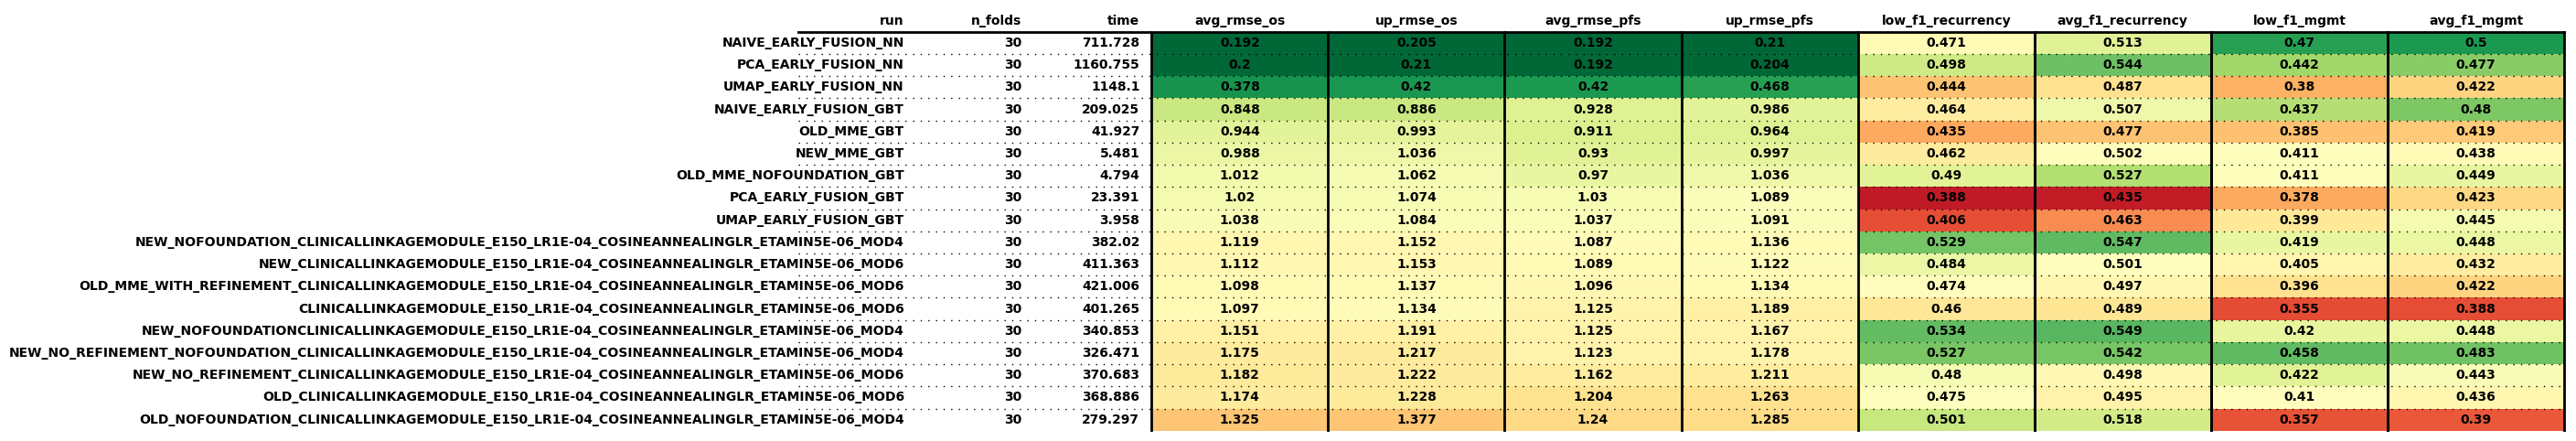

In [30]:
plot_cv_table('../results/cv_results.csv', save=True, out_file="results/cv_results_table.pdf")

## Save ClinicalLinkageModule

In [31]:
save_model(clm, '../saved_models/new_onlyFoundation_clm_no_refinement.ckpt')


Model saved at path: /home/sagemaker-user/gbm_hackathon/saved_models/new_noFoundation_clm_no_refinement.ckpt
Model config saved at cfg_path: /home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_noFoundation_clm_no_refinement.ckpt
You can load it by doing loaded_model = load_model(model_class, path, cfg_path, device)


(PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/new_noFoundation_clm_no_refinement.ckpt'),
 PosixPath('/home/sagemaker-user/gbm_hackathon/saved_models/cfg_new_noFoundation_clm_no_refinement.ckpt'))